In [ ]:
# Run if needed
# I used bikewloops environment 

!pip install networkx
!pip install osmnx

# Run once if these packages are not already installed.
%pip install osmnx python-igraph geopandas matplotlib pandas shapely

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import lzma
import pickle
import shapely
from IPython.display import display
from shapely.geometry import Point

ox.settings.use_cache = False
ox.settings.log_console = False

# the warnings are too annoying, so we ignore them for now
import warnings
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered",
    category=RuntimeWarning
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning
)

# OSM Bike Network of Sample

In [3]:
sample = "Bornholm, Denmark"
output_dir = Path("outputs/bornholm")
output_dir.mkdir(exist_ok=True)

place_gdf = ox.geocode_to_gdf(sample)
place_poly = place_gdf.geometry.union_all()

# retain_all=True keeps disconnected bike-accessible components.
G = ox.graph_from_polygon(
    place_poly,
    network_type="bike",
    retain_all=True,
    simplify=True,
)

G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

print(type(G_proj))
print("Directed:", G_proj.is_directed())
print("CRS:", graph_crs)
print("Nodes:", G_proj.number_of_nodes())
print("Edges:", G_proj.number_of_edges())

graph_path = output_dir / "bornholm_bike_network.graphml"
boundary_path = output_dir / "bornholm_boundary.geojson"

ox.io.save_graphml(G_proj, graph_path)
place_gdf.to_file(boundary_path, driver="GeoJSON")

print("Saved graph to:", graph_path)
print("Saved boundary to:", boundary_path)

ConnectionError: HTTPSConnectionPool(host='overpass-api.de', port=443): Max retries exceeded with url: /api/interpreter (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x31a608d40>: Failed to establish a new connection: [Errno 61] Connection refused'))

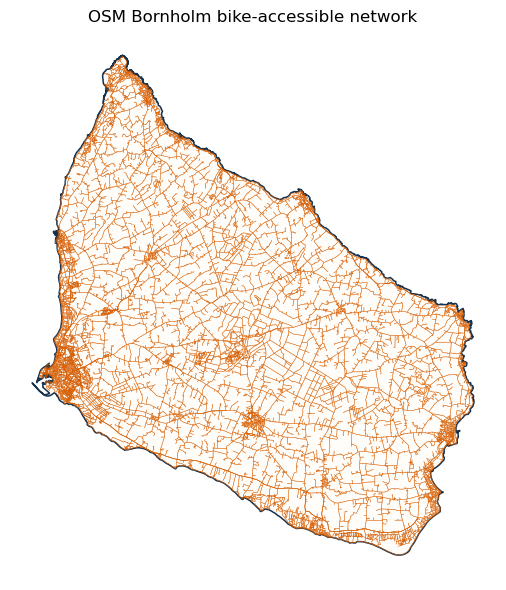

In [ ]:
boundary_proj = place_gdf.to_crs(graph_crs)
nodes, edges = ox.graph_to_gdfs(G_proj)

fig, ax = plt.subplots(figsize=(6, 6))

boundary_proj.plot(ax=ax, facecolor="#fffdf9", edgecolor="#16324f", linewidth=1.1, zorder=1,)

edges.plot(ax=ax, color="#d95f02", linewidth=0.32, alpha=0.82, zorder=2, )
ax.set_title("OSM Bornholm bike-accessible network", fontsize=12)
ax.set_axis_off()
fig.tight_layout()

plot_path = output_dir / "bornholm_bike_network.png"
fig.savefig(plot_path, bbox_inches="tight")
plt.show()

# Bornholm network overlap analysis

Compare the processed BikeNodePlanner / knudepunkter network with the OpenStreetMap bike-accessible network for Bornholm.

NOTE: we refer to bikewloops as `STUDY`

The notebook measures overlap in both directions:
- Study coverage by OSM: percentage of the unique knudepunkter line length lying within a given distance of an OSM bike-accessible line.
- OSM coverage by the study network: percentage of the unique OSM bike-network length lying within a given distance of a knudepunkter line.
- Node proximity: percentage of knudepunkter nodes within each distance threshold of OSM linework.
Several tolerances are reported because independently digitized lines rarely coincide exactly. A 20 m tolerance is used for the detailed map and link classification; adjust it below if needed.

In [ ]:
SAMPLE = "bornholm" # options: bornholm, denmark, funen, jutland, lollandfalster, longland, zealand

STUDY_GRAPH_PATH = Path(
    "/Users/ellenebdrup/Documents/GitHub/bike_safety/"
    f"bikenwloops/data/processed/{SAMPLE}/network_preprocessed0.xz"
)

# This is the GraphML created by the earlier SAMPLE OSMnx notebook.
# If it is absent, the next section downloads the network again.
OSM_GRAPH_PATH = Path(f"outputs/{SAMPLE}/{SAMPLE}_bike_network.graphml")

OUTPUT_DIR = Path(f"outputs/{SAMPLE}/overlap_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STUDY_CRS = "EPSG:25832"  # CRS used by the bikenwloops study
TOLERANCES_M = [5, 10, 20, 30, 50]
DETAIL_TOLERANCE_M = 20

# The bikenwloops preprocessing applied this offset to SAMPLE for plotting.
# It must be reversed to restore SAMPLE's real EPSG:25832 position.
STUDY_STORED_OFFSET_M = (-220_000, 120_000)
UNDO_STUDY_OFFSET = True

assert STUDY_GRAPH_PATH.exists(), f"Study graph not found: {STUDY_GRAPH_PATH}"
print("Study graph:", STUDY_GRAPH_PATH)
print("OSM graph exists:", OSM_GRAPH_PATH.exists())
print("Results folder:", OUTPUT_DIR.resolve())

Study graph: /Users/ellenebdrup/Documents/GitHub/bike_safety/bikenwloops/data/processed/bornholm/network_preprocessed0.xz
OSM graph exists: True
Results folder: /Users/ellenebdrup/Documents/GitHub/bike_safety/osm_data_exploration/outputs/overlap_analysis


In [5]:
# investigate the graph from bikewloops:
with lzma.open(STUDY_GRAPH_PATH, "rb") as file:
    study_graph = pickle.load(file)

print(study_graph.summary())
print("Directed:", study_graph.is_directed())
print("Vertex attributes:", study_graph.vs.attribute_names())
print("Edge attributes:", study_graph.es.attribute_names())

IGRAPH UNW- 59 89 -- 
+ attr: id_cykelknudepkt (v), name (v), x (v), y (v), edge_id (e), geometry (e), max_slope (e), weight (e)
Directed: False
Vertex attributes: ['name', 'id_cykelknudepkt', 'x', 'y']
Edge attributes: ['weight', 'edge_id', 'max_slope', 'geometry']


In [28]:
# Convert igraph vertices and edges to GeoDataFrames.
node_records = []
for vertex in study_graph.vs:
    attrs = vertex.attributes().copy()
    attrs["igraph_index"] = vertex.index
    attrs["geometry"] = Point(attrs["x"], attrs["y"])
    node_records.append(attrs)

edge_records = []
for edge in study_graph.es:
    attrs = edge.attributes().copy()
    attrs["source"], attrs["target"] = edge.tuple
    edge_records.append(attrs)

study_nodes = gpd.GeoDataFrame(node_records, geometry="geometry", crs=STUDY_CRS)
study_edges = gpd.GeoDataFrame(edge_records, geometry="geometry", crs=STUDY_CRS)
study_edges = study_edges.loc[
    study_edges.geometry.notna() & ~study_edges.geometry.is_empty
].copy()

if UNDO_STUDY_OFFSET:
    undo_x = -STUDY_STORED_OFFSET_M[0]
    undo_y = -STUDY_STORED_OFFSET_M[1]
    study_nodes["geometry"] = study_nodes.geometry.translate(xoff=undo_x, yoff=undo_y)
    study_edges["geometry"] = study_edges.geometry.translate(xoff=undo_x, yoff=undo_y)
    study_nodes["x"] = study_nodes.geometry.x
    study_nodes["y"] = study_nodes.geometry.y
    print(f"Reversed stored Bornholm offset: x {undo_x:+,} m, y {undo_y:+,} m")

print(f"Study nodes: {len(study_nodes):,}")
print(f"Study links: {len(study_edges):,}")
print("Study CRS:", study_edges.crs)
display(study_edges.head(3))

Reversed stored Bornholm offset: x +220,000 m, y -120,000 m
Study nodes: 59
Study links: 89
Study CRS: EPSG:25832


,weight,edge_id,max_slope,geometry,source,target
0,4070.941878,0,3.750957,"LINESTRING (884790.176 6111667.992, 884809.13 ...",0,1
1,5059.992235,1,4.673647,"LINESTRING (881658.93 6114106.8, 881668.7 6114...",0,2
2,3526.484593,2,4.319620,"LINESTRING (884790.176 6111667.992, 884790.75 ...",0,3


In [29]:
if OSM_GRAPH_PATH.exists():
    G_osm = ox.load_graphml(OSM_GRAPH_PATH)
    print("Loaded the existing OSM GraphML file.")
else:
    print("OSM GraphML not found; downloading Bornholm from OpenStreetMap...")
    G_osm = ox.graph_from_place(
        "Bornholm, Denmark",
        network_type="bike",
        retain_all=True,
        simplify=True,
    )
    G_osm = ox.project_graph(G_osm)
    OSM_GRAPH_PATH.parent.mkdir(parents=True, exist_ok=True)
    ox.save_graphml(G_osm, OSM_GRAPH_PATH)

osm_nodes, osm_edges = ox.graph_to_gdfs(G_osm)

# Put both datasets in the study's metre-based CRS.
osm_nodes = osm_nodes.to_crs(STUDY_CRS)
osm_edges = osm_edges.to_crs(STUDY_CRS)

print(type(G_osm))
print("Directed:", G_osm.is_directed())
print(f"OSM nodes: {len(osm_nodes):,}")
print(f"OSM directed edges: {len(osm_edges):,}")
print("Analysis CRS:", osm_edges.crs)

Loaded the existing OSM GraphML file.
<class 'networkx.classes.multidigraph.MultiDiGraph'>
Directed: True
OSM nodes: 26,330
OSM directed edges: 61,331
Analysis CRS: EPSG:25832


### 4. Create unique physical line networks
OSMnx represents bicycle travel as a directed graph, so the same physical line can appear once in each direction. Dissolving the geometries prevents those duplicates from inflating the length totals. The study linework is dissolved for the same reason.

In [30]:
study_network = shapely.union_all(study_edges.geometry.array)
osm_network = shapely.union_all(osm_edges.geometry.array)

study_length_m = study_network.length
osm_length_m = osm_network.length

network_summary = pd.DataFrame(
    {
        "network": ["Knudepunkter study network", "OSM bike-accessible network"],
        "unique_length_km": [study_length_m / 1000, osm_length_m / 1000],
        "nodes": [len(study_nodes), len(osm_nodes)],
        "stored_edges": [len(study_edges), len(osm_edges)],
    }
)
display(network_summary.round(2))

,network,unique_length_km,nodes,stored_edges
0,Knudepunkter study network,375.73,59,89
1,OSM bike-accessible network,3100.08,26330,61331


### 5. Calculate length and node overlap across tolerances
For each tolerance, the notebook buffers one network and measures how much of the other network falls inside that buffer. This is a line-coverage measure, not merely a bounding-box intersection.

In [31]:
# Use spatial indexes so the full-island comparison remains fast.
nearest_node_matches = gpd.sjoin_nearest(
    study_nodes[["geometry"]],
    osm_edges[["geometry"]],
    how="left",
    distance_col="distance_to_osm_m",
)
study_nodes["distance_to_osm_m"] = (
    nearest_node_matches.groupby(level=0)["distance_to_osm_m"].min()
)

# Only OSM edges close enough to possibly overlap the study network are
# needed for the numerators. The denominator still uses all OSM linework.
maximum_buffer = study_network.buffer(max(TOLERANCES_M))
candidate_positions = osm_edges.sindex.query(maximum_buffer, predicate="intersects")
osm_edges_near_study = osm_edges.iloc[np.unique(candidate_positions)].copy()
osm_near_study_network = shapely.union_all(osm_edges_near_study.geometry.array)
print(f"OSM edges close enough to compare: {len(osm_edges_near_study):,}")

overlap_rows = []
for tolerance_m in TOLERANCES_M:
    osm_buffer = osm_near_study_network.buffer(tolerance_m)
    study_buffer = study_network.buffer(tolerance_m)

    study_covered_m = study_network.intersection(osm_buffer).length
    osm_covered_m = osm_near_study_network.intersection(study_buffer).length
    nodes_covered = int((study_nodes["distance_to_osm_m"] <= tolerance_m).sum())

    overlap_rows.append(
        {
            "tolerance_m": tolerance_m,
            "study_covered_km": study_covered_m / 1000,
            "study_coverage_pct": 100 * study_covered_m / study_length_m,
            "osm_covered_km": osm_covered_m / 1000,
            "osm_coverage_pct": 100 * osm_covered_m / osm_length_m,
            "study_nodes_near_osm": nodes_covered,
            "study_node_coverage_pct": 100 * nodes_covered / len(study_nodes),
        }
    )

overlap = pd.DataFrame(overlap_rows)
overlap.to_csv(OUTPUT_DIR / "overlap_by_tolerance.csv", index=False)
display(overlap.round(2))

OSM edges close enough to compare: 16,352


,tolerance_m,study_covered_km,study_coverage_pct,osm_covered_km,osm_coverage_pct,study_nodes_near_osm,study_node_coverage_pct
0,5,369.60,98.37,398.15,12.84,56,94.92
1,10,374.35,99.63,490.78,15.83,57,96.61
2,20,374.81,99.76,536.34,17.30,59,100.00
3,30,375.06,99.82,576.03,18.58,59,100.00
4,50,375.29,99.88,655.06,21.13,59,100.00


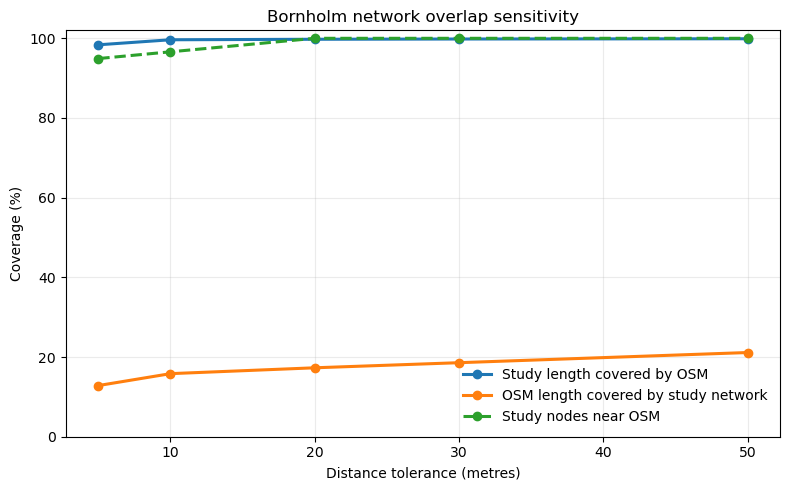

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    overlap["tolerance_m"],
    overlap["study_coverage_pct"],
    marker="o",
    linewidth=2.2,
    label="Study length covered by OSM",
)
ax.plot(
    overlap["tolerance_m"],
    overlap["osm_coverage_pct"],
    marker="o",
    linewidth=2.2,
    label="OSM length covered by study network",
)
ax.plot(
    overlap["tolerance_m"],
    overlap["study_node_coverage_pct"],
    marker="o",
    linewidth=2.2,
    linestyle="--",
    label="Study nodes near OSM",
)
ax.set(
    xlabel="Distance tolerance (metres)",
    ylabel="Coverage (%)",
    title="Bornholm network overlap sensitivity",
    ylim=(0, 102),
)
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "overlap_by_tolerance.png", dpi=220, bbox_inches="tight")
plt.show()

### 6. Classify every study link at the detailed tolerance
Links are classified by the share of their length lying within the selected OSM buffer:
- Matched: at least 90%
- Partial: 10% to less than 90%
- Unmatched: less than 10%

In [33]:
osm_detail_buffer = osm_near_study_network.buffer(DETAIL_TOLERANCE_M)

study_edges["link_length_m"] = study_edges.geometry.length
study_edges["covered_length_m"] = study_edges.geometry.apply(
    lambda geom: geom.intersection(osm_detail_buffer).length
)
study_edges["coverage_pct"] = np.where(
    study_edges["link_length_m"] > 0,
    100 * study_edges["covered_length_m"] / study_edges["link_length_m"],
    np.nan,
)
study_edges["overlap_class"] = pd.cut(
    study_edges["coverage_pct"],
    bins=[-np.inf, 10, 90, np.inf],
    labels=["Unmatched (<10%)", "Partial (10–<90%)", "Matched (≥90%)"],
    right=False,
)

link_summary = (
    study_edges.groupby("overlap_class", observed=False)
    .agg(
        links=("edge_id", "count"),
        total_link_km=("link_length_m", lambda values: values.sum() / 1000),
        mean_coverage_pct=("coverage_pct", "mean"),
    )
    .reset_index()
)
study_edges.to_file(OUTPUT_DIR / "study_link_overlap.gpkg", layer="links", driver="GPKG")
link_summary.to_csv(OUTPUT_DIR / "study_link_overlap_summary.csv", index=False)
display(link_summary.round(2))

,overlap_class,links,total_link_km,mean_coverage_pct
0,Unmatched (<10%),0,0.00,NaN
1,Partial (10–<90%),0,0.00,NaN
2,Matched (≥90%),89,375.73,99.87


### 7. Map matched and unmatched portions
Green shows study-network linework within the selected distance of OSM. Red shows study-network linework outside it. The full OSM bike-accessible network is shown in light grey for context.

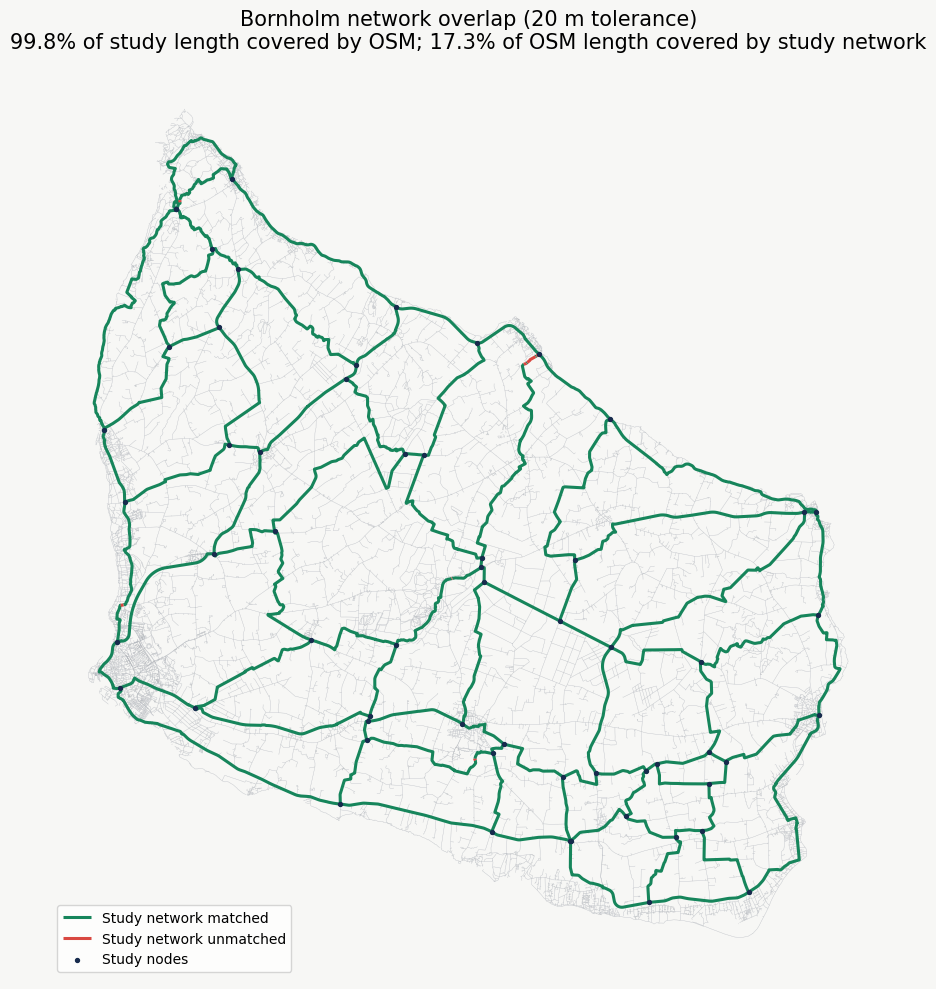

In [ ]:
matched_geometry = study_network.intersection(osm_detail_buffer)
unmatched_geometry = study_network.difference(osm_detail_buffer)

matched_gs = gpd.GeoSeries([matched_geometry], crs=STUDY_CRS)
unmatched_gs = gpd.GeoSeries([unmatched_geometry], crs=STUDY_CRS)

detail_row = overlap.loc[overlap["tolerance_m"] == DETAIL_TOLERANCE_M].iloc[0]

fig, ax = plt.subplots(figsize=(11, 10), facecolor="#f7f7f5")
osm_edges.plot(ax=ax, color="#b8bcc2", linewidth=0.25, alpha=0.55, zorder=1)
matched_gs.plot(ax=ax, color="#16855b", linewidth=2.2, zorder=3, label="Study network matched")
if not unmatched_geometry.is_empty:
    unmatched_gs.plot(ax=ax, color="#d94841", linewidth=2.2, zorder=4, label="Study network unmatched")
study_nodes.plot(ax=ax, color="#172b4d", markersize=9, zorder=5, label="Study nodes")

ax.set_title(
    f"Bornholm network overlap ({DETAIL_TOLERANCE_M} m tolerance)\n"
    f"{detail_row['study_coverage_pct']:.1f}% of study length covered by OSM; "
    f"{detail_row['osm_coverage_pct']:.1f}% of OSM length covered by study network",
    fontsize=15,
    pad=14,
)
ax.legend(frameon=True, loc="lower left")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "bornholm_network_overlap_map.png", dpi=240, bbox_inches="tight")
plt.show()

In [35]:
link_columns = [
    column
    for column in ["edge_id", "source", "target", "link_length_m", "coverage_pct", "overlap_class"]
    if column in study_edges.columns
]
lowest_coverage_links = study_edges[link_columns].sort_values("coverage_pct").head(20)
farthest_nodes = (
    study_nodes.drop(columns="geometry")
    .sort_values("distance_to_osm_m", ascending=False)
    .head(20)
)

lowest_coverage_links.to_csv(OUTPUT_DIR / "lowest_coverage_links.csv", index=False)
farthest_nodes.to_csv(OUTPUT_DIR / "farthest_nodes_from_osm.csv", index=False)

print("Study links with the lowest OSM coverage:")
display(lowest_coverage_links.round(2))
print("Study nodes farthest from OSM linework:")
display(farthest_nodes.round(2))

Study links with the lowest OSM coverage:


,edge_id,source,target,link_length_m,coverage_pct,overlap_class
65,65,40,47,10499.53,94.03,Matched (≥90%)
88,88,57,58,3707.19,97.76,Matched (≥90%)
46,49,27,37,6263.73,98.23,Matched (≥90%)
23,25,12,14,6357.48,98.86,Matched (≥90%)
51,46,30,34,5389.03,99.55,Matched (≥90%)
41,37,23,29,199.67,100.00,Matched (≥90%)
40,35,23,24,3919.85,100.00,Matched (≥90%)
66,68,41,44,1356.35,100.00,Matched (≥90%)
17,19,9,18,2787.06,100.00,Matched (≥90%)
14,12,7,11,6181.67,100.00,Matched (≥90%)


Study nodes farthest from OSM linework:


,name,id_cykelknudepkt,x,y,igraph_index,distance_to_osm_m
27,29,"['vk2551', 'vk2552', 'vk2550']",863655.06,6122019.88,27,11.60
15,20,"['vk2571', 'vk2570', 'vk2569', 'vk2568', 'vk28...",863748.46,6120201.90,15,11.28
41,42,"['vk2819', 'vk2572', 'vk2573', 'vk2818']",869333.55,6129581.46,41,6.58
28,31,['vk2561'],878246.97,6124408.01,28,3.58
42,43,"['vk2841', 'vk2842', 'vk2843', 'vk2608', 'vk26...",883259.94,6130890.32,42,1.94
49,48,['vk2540'],872750.04,6132500.24,49,1.31
4,4,['vk2755'],886896.12,6114528.37,4,1.20
14,17,['vk2596'],873572.39,6118111.61,14,1.01
45,46,"['vk2576', 'vk4555', 'vk4557']",863127.25,6130453.51,45,0.87
31,28,['vk2582'],871357.39,6122102.89,31,0.86


In [50]:
# ============================================================
# DETAILED ANALYSIS OF UNMATCHED (RED) NETWORK SEGMENTS
# ============================================================

def extract_line_parts(geometry):
    """Recursively extract LineStrings from multipart geometries."""
    if geometry is None or geometry.is_empty:
        return

    if geometry.geom_type == "LineString":
        yield geometry

    elif hasattr(geometry, "geoms"):
        for part in geometry.geoms:
            yield from extract_line_parts(part)


# Recalculate unmatched geometry separately for every original
# study edge so each red segment retains its edge ID.
unmatched_records = []

attribute_columns = [
    column
    for column in [
        "edge_id",
        "source",
        "target",
        "link_length_m",
        "coverage_pct",
        "overlap_class",
    ]
    if column in study_edges.columns
]

for edge_index, edge in study_edges.iterrows():
    edge_unmatched = edge.geometry.difference(
        osm_detail_buffer
    )

    for geometry in extract_line_parts(edge_unmatched):
        # Ignore microscopic fragments caused by geometry precision.
        if geometry.length < 1:
            continue

        record = {
            column: edge[column]
            for column in attribute_columns
        }

        record.update(
            {
                "study_edge_index": str(edge_index),
                "unmatched_length_m": geometry.length,
                "geometry": geometry,
            }
        )

        unmatched_records.append(record)


unmatched_segments = gpd.GeoDataFrame(
    unmatched_records,
    geometry="geometry",
    crs=STUDY_CRS,
)

unmatched_segments["segment_id"] = np.arange(
    1,
    len(unmatched_segments) + 1,
)

unmatched_segments = (
    unmatched_segments
    .sort_values(
        "unmatched_length_m",
        ascending=False,
    )
    .reset_index(drop=True)
)

print(
    f"Number of unmatched segments: "
    f"{len(unmatched_segments)}"
)

print(
    f"Total unmatched length: "
    f"{unmatched_segments['unmatched_length_m'].sum():.1f} m"
)

display_columns = [
    column
    for column in [
        "segment_id",
        "edge_id",
        "source",
        "target",
        "unmatched_length_m",
        "link_length_m",
        "coverage_pct",
        "overlap_class",
    ]
    if column in unmatched_segments.columns
]

display(
    unmatched_segments[display_columns].round(2)
)

Number of unmatched segments: 7
Total unmatched length: 917.6 m


,segment_id,edge_id,source,target,unmatched_length_m,link_length_m,coverage_pct,overlap_class
0,5,65,40,47,410.53,10499.53,94.03,Matched (≥90%)
1,4,65,40,47,113.32,10499.53,94.03,Matched (≥90%)
2,2,49,27,37,110.62,6263.73,98.23,Matched (≥90%)
3,6,65,40,47,103.22,10499.53,94.03,Matched (≥90%)
4,7,88,57,58,83.22,3707.19,97.76,Matched (≥90%)
5,1,25,12,14,72.60,6357.48,98.86,Matched (≥90%)
6,3,46,30,34,24.09,5389.03,99.55,Matched (≥90%)


In [51]:
# Convert OSM's u-v-key index into ordinary columns.
osm_edges_lookup = osm_edges.reset_index()

# Use the midpoint of each red segment for nearest-edge inspection.
unmatched_midpoints = gpd.GeoDataFrame(
    {
        "segment_id": unmatched_segments["segment_id"],
    },
    geometry=unmatched_segments.geometry.interpolate(
        0.5,
        normalized=True,
    ),
    crs=STUDY_CRS,
)

osm_attribute_columns = [
    column
    for column in [
        "u",
        "v",
        "key",
        "osmid",
        "name",
        "highway",
        "bicycle",
        "access",
        "surface",
        "tracktype",
        "service",
        "geometry",
    ]
    if column in osm_edges_lookup.columns
]

nearest_osm = gpd.sjoin_nearest(
    unmatched_midpoints,
    osm_edges_lookup[osm_attribute_columns],
    how="left",
    distance_col="midpoint_distance_to_osm_m",
)

# OSMnx normally contains two directed versions of the same
# physical edge. Keep one nearest result per red segment.
nearest_osm = (
    nearest_osm
    .sort_values("midpoint_distance_to_osm_m")
    .drop_duplicates("segment_id")
)

nearest_osm_attributes = nearest_osm.drop(
    columns=[
        "geometry",
        "index_right",
    ],
    errors="ignore",
)

unmatched_segments = unmatched_segments.merge(
    nearest_osm_attributes,
    on="segment_id",
    how="left",
)

inspection_columns = [
    column
    for column in [
        "segment_id",
        "edge_id",
        "unmatched_length_m",
        "midpoint_distance_to_osm_m",
        "osmid",
        "name",
        "highway",
        "bicycle",
        "access",
        "surface",
    ]
    if column in unmatched_segments.columns
]

print("Nearest OSM edge to each unmatched segment:")

display(
    unmatched_segments[inspection_columns]
    .sort_values(
        "unmatched_length_m",
        ascending=False,
    )
    .round(2)
)



Nearest OSM edge to each unmatched segment:


,segment_id,edge_id,unmatched_length_m,midpoint_distance_to_osm_m,osmid,name,highway,access
0,5,65,410.53,131.55,232690997,NaN,path,NaN
1,4,65,113.32,74.52,"[232690995, 232690997, 232690999]",NaN,path,NaN
2,2,49,110.62,25.87,187736132,NaN,path,NaN
3,6,65,103.22,69.61,215112383,NaN,cycleway,NaN
4,7,88,83.22,37.35,62324198,NaN,track,NaN
5,1,25,72.60,45.84,108928691,Haregade,residential,NaN
6,3,46,24.09,31.93,709572024,Almindingsvej,track,NaN


#### Measure distances along each red segment

In [52]:
SAMPLE_INTERVAL_M = 10

sample_records = []
sample_id = 0

for _, segment in unmatched_segments.iterrows():
    geometry = segment.geometry

    sample_distances = np.arange(
        0,
        geometry.length + SAMPLE_INTERVAL_M,
        SAMPLE_INTERVAL_M,
    )

    sample_distances = np.clip(
        sample_distances,
        0,
        geometry.length,
    )

    for distance_along in np.unique(sample_distances):
        sample_records.append(
            {
                "sample_id": sample_id,
                "segment_id": segment["segment_id"],
                "distance_along_segment_m": distance_along,
                "geometry": geometry.interpolate(
                    distance_along
                ),
            }
        )

        sample_id += 1


unmatched_sample_points = gpd.GeoDataFrame(
    sample_records,
    geometry="geometry",
    crs=STUDY_CRS,
)

sample_nearest_osm = gpd.sjoin_nearest(
    unmatched_sample_points,
    osm_edges_lookup[["geometry"]],
    how="left",
    distance_col="distance_to_osm_m",
)

# Remove duplicates caused by OSM directionality.
sample_nearest_osm = (
    sample_nearest_osm
    .sort_values("distance_to_osm_m")
    .drop_duplicates("sample_id")
)

segment_distance_summary = (
    sample_nearest_osm
    .groupby("segment_id")
    .agg(
        minimum_distance_m=(
            "distance_to_osm_m",
            "min",
        ),
        median_distance_m=(
            "distance_to_osm_m",
            "median",
        ),
        maximum_distance_m=(
            "distance_to_osm_m",
            "max",
        ),
        number_of_samples=(
            "sample_id",
            "count",
        ),
    )
    .reset_index()
)

unmatched_segments = unmatched_segments.merge(
    segment_distance_summary,
    on="segment_id",
    how="left",
)

distance_columns = [
    "segment_id",
    "edge_id",
    "unmatched_length_m",
    "minimum_distance_m",
    "median_distance_m",
    "maximum_distance_m",
]

display(
    unmatched_segments[distance_columns]
    .sort_values(
        "unmatched_length_m",
        ascending=False,
    )
    .round(2)
)

,segment_id,edge_id,unmatched_length_m,minimum_distance_m,median_distance_m,maximum_distance_m
0,5,65,410.53,19.98,112.84,140.94
1,4,65,113.32,20.00,43.07,71.48
2,2,49,110.62,20.00,25.98,28.03
3,6,65,103.22,19.98,41.08,69.97
4,7,88,83.22,19.99,29.55,45.12
5,1,25,72.60,19.98,32.51,48.96
6,3,46,24.09,19.98,22.03,29.90


#### Plot and label all red segments

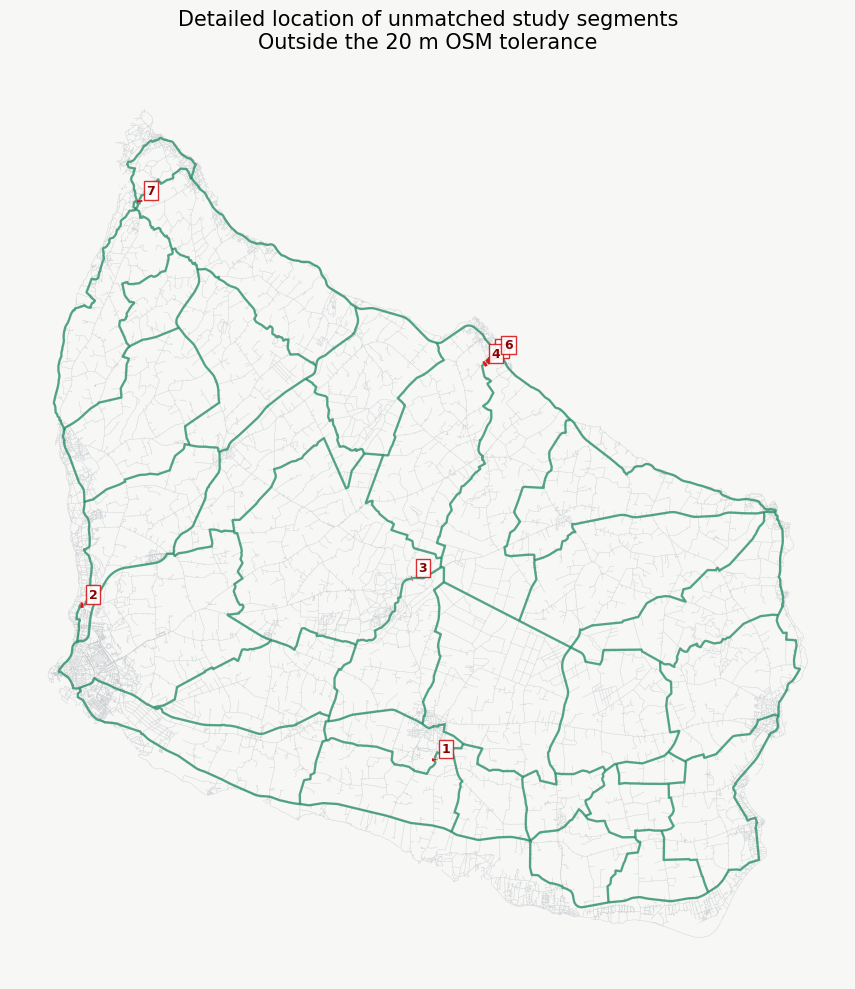

In [53]:
fig, ax = plt.subplots(
    figsize=(11, 10),
    facecolor="#f7f7f5",
)

osm_edges.plot(
    ax=ax,
    color="#c8cdd2",
    linewidth=0.3,
    alpha=0.5,
    zorder=1,
)

matched_gs.plot(
    ax=ax,
    color="#16855b",
    linewidth=1.7,
    alpha=0.7,
    zorder=2,
)

unmatched_segments.plot(
    ax=ax,
    color="#d7191c",
    linewidth=4,
    zorder=4,
)

# Label red segments using their segment IDs.
for _, segment in unmatched_segments.iterrows():
    label_point = segment.geometry.interpolate(
        0.5,
        normalized=True,
    )

    ax.annotate(
        str(segment["segment_id"]),
        xy=(label_point.x, label_point.y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color="#8b0000",
        bbox={
            "facecolor": "white",
            "edgecolor": "#d7191c",
            "alpha": 0.9,
            "pad": 2,
        },
        zorder=5,
    )

ax.set_title(
    "Detailed location of unmatched study segments\n"
    f"Outside the {DETAIL_TOLERANCE_M} m OSM tolerance",
    fontsize=15,
    pad=14,
)

ax.set_axis_off()
ax.set_aspect("equal")
fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "unmatched_segments_numbered.png",
    dpi=240,
    bbox_inches="tight",
)

plt.show()

#### Produce a close-up panel for every red segment

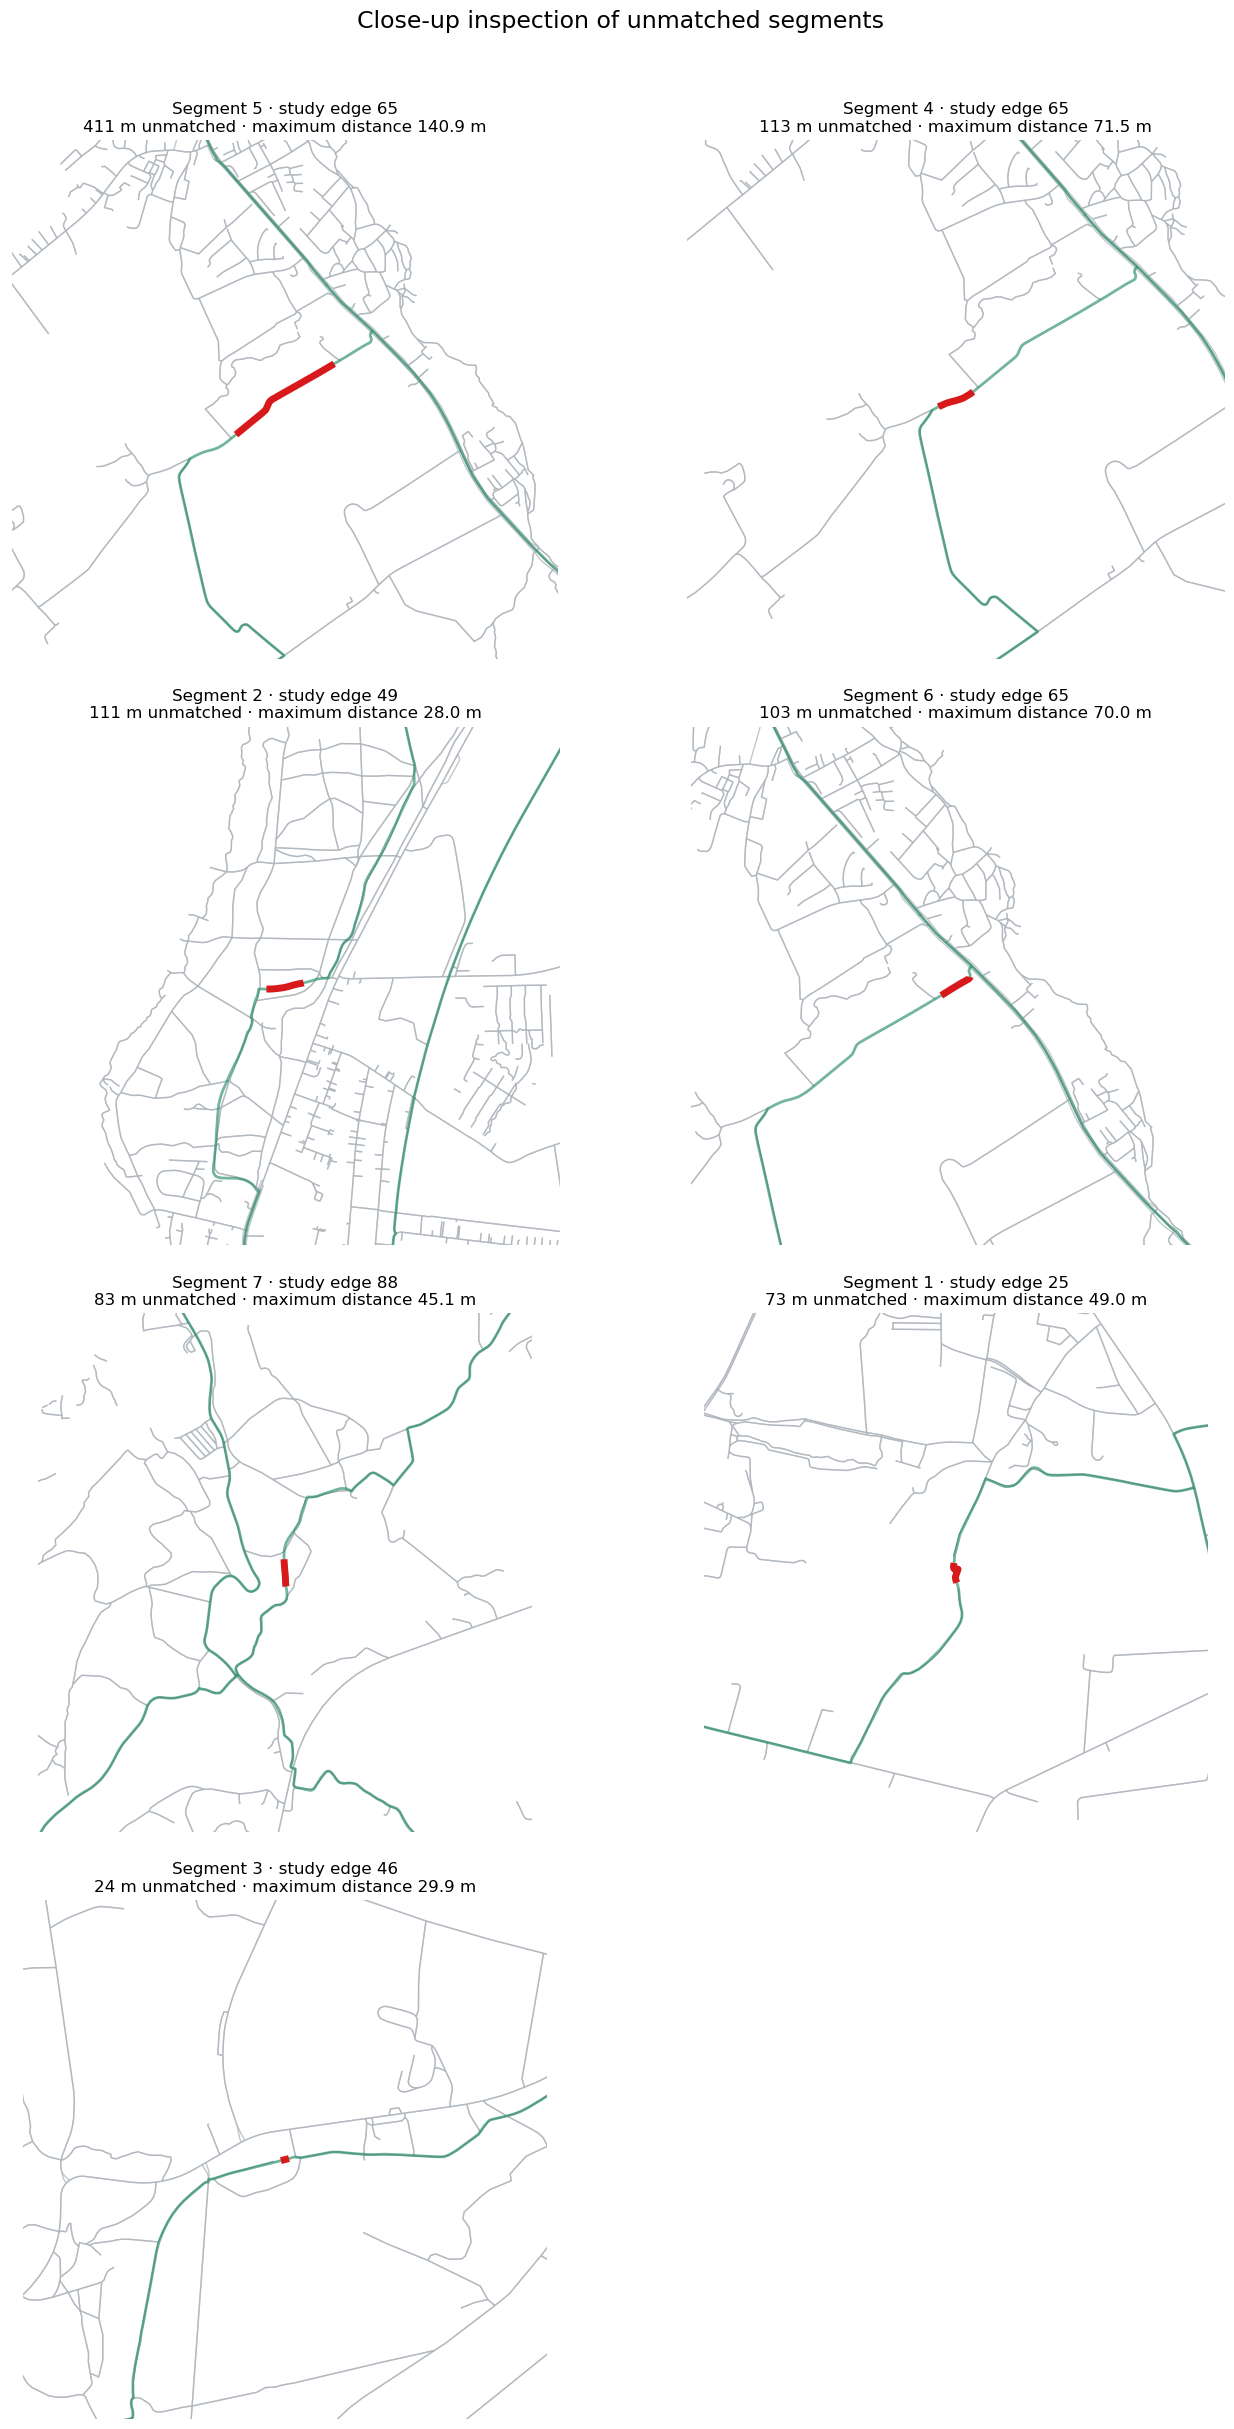

In [54]:
ZOOM_BUFFER_M = 750

number_of_segments = len(unmatched_segments)
number_of_columns = 2
number_of_rows = int(
    np.ceil(number_of_segments / number_of_columns)
)

fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(14, 6 * number_of_rows),
)

axes = np.atleast_1d(axes).ravel()

for ax, (_, segment) in zip(
    axes,
    unmatched_segments.iterrows(),
):
    zoom_area = segment.geometry.buffer(
        ZOOM_BUFFER_M
    )

    minx, miny, maxx, maxy = zoom_area.bounds

    nearby_osm = osm_edges.cx[
        minx:maxx,
        miny:maxy,
    ]

    nearby_study = study_edges.cx[
        minx:maxx,
        miny:maxy,
    ]

    nearby_osm.plot(
        ax=ax,
        color="#aeb5bc",
        linewidth=1,
        alpha=0.75,
        zorder=1,
    )

    nearby_study.plot(
        ax=ax,
        color="#16855b",
        linewidth=2,
        alpha=0.6,
        zorder=2,
    )

    gpd.GeoSeries(
        [segment.geometry],
        crs=STUDY_CRS,
    ).plot(
        ax=ax,
        color="#d7191c",
        linewidth=5,
        zorder=4,
    )

    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    ax.set_aspect("equal")
    ax.set_axis_off()

    ax.set_title(
        f"Segment {segment['segment_id']} · "
        f"study edge {segment['edge_id']}\n"
        f"{segment['unmatched_length_m']:.0f} m unmatched · "
        f"maximum distance "
        f"{segment['maximum_distance_m']:.1f} m"
    )

# Hide unused subplot panels.
for ax in axes[number_of_segments:]:
    ax.set_visible(False)

fig.suptitle(
    "Close-up inspection of unmatched segments",
    fontsize=17,
    y=1.01,
)

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR / "unmatched_segments_closeups.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()



# bikewloops Bornholm input data

### 1. File paths and parameters

In [37]:
BIKELOOPS_DIR = Path(
    "/Users/ellenebdrup/Documents/GitHub/"
    "bike_safety/bikenwloops"
)

INPUT_DIR = (
    BIKELOOPS_DIR
    / "data/input/bornholm/network/processed"
)

BIKENODE_EDGES_PATH = INPUT_DIR / "edges_slope.gpkg"
BIKENODE_NODES_PATH = INPUT_DIR / "nodes.gpkg"

# Existing OSMnx network from the earlier analysis.
OSM_GRAPH_PATH = Path(
    "/Users/ellenebdrup/Documents/Codex/2026-09-11/loa/"
    "outputs/bornholm_bike_network.graphml"
)

OUTPUT_DIR = Path("outputs/bornholm_osm_matching")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Lines within this distance are considered spatially matched.
MATCH_TOLERANCE_M = 20

# Edge-level classification thresholds.
PARTIAL_THRESHOLD_PCT = 10
MATCHED_THRESHOLD_PCT = 90

print("BikeNode edges:", BIKENODE_EDGES_PATH)
print("BikeNode nodes:", BIKENODE_NODES_PATH)
print("OSM graph:", OSM_GRAPH_PATH)

BikeNode edges: /Users/ellenebdrup/Documents/GitHub/bike_safety/bikenwloops/data/input/bornholm/network/processed/edges_slope.gpkg
BikeNode nodes: /Users/ellenebdrup/Documents/GitHub/bike_safety/bikenwloops/data/input/bornholm/network/processed/nodes.gpkg
OSM graph: /Users/ellenebdrup/Documents/Codex/2026-09-11/loa/outputs/bornholm_bike_network.graphml


### 2. Load the BikeNodePlanner input data

In [38]:
bikenode_edges = gpd.read_file(BIKENODE_EDGES_PATH)
bikenode_nodes = gpd.read_file(BIKENODE_NODES_PATH)

print("BikeNode CRS:", bikenode_edges.crs)
print("BikeNode edges:", len(bikenode_edges))
print("BikeNode nodes:", len(bikenode_nodes))

display(bikenode_edges.head())
display(bikenode_nodes.head())

BikeNode CRS: EPSG:25832
BikeNode edges: 89
BikeNode nodes: 59


,mm_len,node_start,node_end,edge_id,min_slope,max_slope,ave_slope,geometry
0,4070.941878,0,1,0,0.003704,3.750957,0.640971,"LINESTRING (884790.176 6111667.992, 884809.13 ..."
1,5059.992235,0,2,1,0.015633,4.673647,0.782629,"LINESTRING (881658.93 6114106.8, 881668.7 6114..."
2,3526.484593,0,3,2,0.035969,4.319620,0.991292,"LINESTRING (884790.176 6111667.992, 884790.75 ..."
3,3894.576779,1,4,3,0.037268,2.770777,0.749578,"LINESTRING (886896.12 6114528.37, 886899.6 611..."
4,9627.531989,1,11,4,0.004103,2.348074,0.548400,"LINESTRING (888758.8 6112075.84, 888772.57 611..."


,nodeID,id_cykelknudepkt,geometry
0,0,['vk2605'],POINT (884790.176 6111667.992)
1,1,['vk2756'],POINT (888758.8 6112075.84)
2,2,['vk2556'],POINT (881658.93 6114106.8)
3,3,['vk2753'],POINT (885859.66 6114266.65)
4,4,['vk2755'],POINT (886896.12 6114528.37)


### 3. Load or download the OSM bicycle network

In [39]:
if OSM_GRAPH_PATH.exists():
    G_osm = ox.load_graphml(OSM_GRAPH_PATH)
    print("Loaded existing OSM network.")
else:
    print("Downloading OSM bicycle network for Bornholm...")

    G_osm = ox.graph_from_place(
        "Bornholm, Denmark",
        network_type="bike",
        retain_all=True,
        simplify=True,
    )

    G_osm = ox.project_graph(G_osm)

    OSM_GRAPH_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    ox.save_graphml(
        G_osm,
        OSM_GRAPH_PATH,
    )

osm_nodes, osm_edges = ox.graph_to_gdfs(G_osm)

# Use the same metre-based CRS as the BikeNodePlanner files.
osm_nodes = osm_nodes.to_crs(bikenode_edges.crs)
osm_edges = osm_edges.to_crs(bikenode_edges.crs)

# Turn the OSM edge index into ordinary columns: u, v and key.
osm_edges = osm_edges.reset_index()

print("OSM CRS:", osm_edges.crs)
print("OSM nodes:", len(osm_nodes))
print("OSM directed edges:", len(osm_edges))

Loaded existing OSM network.
OSM CRS: EPSG:25832
OSM nodes: 26330
OSM directed edges: 61331


### 4. Remove invalid geometry

In [40]:
bikenode_edges = bikenode_edges.loc[
    bikenode_edges.geometry.notna()
    & ~bikenode_edges.geometry.is_empty
].copy()

osm_edges = osm_edges.loc[
    osm_edges.geometry.notna()
    & ~osm_edges.geometry.is_empty
].copy()

# Rebuild positional indexing before using the spatial index.
osm_edges = osm_edges.reset_index(drop=True)

### 5. Helper for collecting OSM identifiers
OSM attributes sometimes contain either one value or a list of values. This helper converts them into a clean list.

In [41]:
def flatten_osm_values(values):
    result = set()

    for value in values.dropna():
        if isinstance(value, (list, tuple, set, np.ndarray)):
            result.update(str(item) for item in value)
        else:
            result.add(str(value))

    return sorted(result)

### 6. Match each BikeNodePlanner edge to OSM
For every BikeNodePlanner edge, this code:
- Finds nearby OSM edges with a spatial index.
- Buffers those OSM edges by 20 metres.
- Measures how much of the BikeNodePlanner edge lies inside the buffer.
- Stores the corresponding OSM IDs, road names and highway types.

In [43]:
# Remove matching columns if this notebook cell has already been run.
previous_match_columns = [
    "study_length_m",
    "covered_length_m",
    "coverage_pct",
    "number_osm_candidates",
    "osm_ids",
    "osm_names",
    "osm_highways",
    "osm_edge_keys",
    "match_class",
]

bikenode_edges = bikenode_edges.drop(
    columns=previous_match_columns,
    errors="ignore",
)

# Ensure positional indexing agrees with .iloc and the spatial index.
osm_edges = osm_edges.reset_index(drop=True)
osm_spatial_index = osm_edges.sindex

match_records = []

for row_index, bikenode_edge in bikenode_edges.iterrows():
    study_geometry = bikenode_edge.geometry
    study_length_m = study_geometry.length

    # Find OSM edges within the selected distance.
    candidate_positions = osm_spatial_index.query(
        study_geometry,
        predicate="dwithin",
        distance=MATCH_TOLERANCE_M,
    )

    candidates = osm_edges.iloc[
        np.unique(candidate_positions)
    ].copy()

    if candidates.empty:
        covered_length_m = 0.0
        osm_ids = []
        osm_names = []
        osm_highways = []
        osm_edge_keys = []

    else:
        # Dissolving prevents opposite directed copies of the same
        # physical OSM line from being counted twice.
        candidate_network = shapely.union_all(
            candidates.geometry.array
        )

        candidate_buffer = candidate_network.buffer(
            MATCH_TOLERANCE_M
        )

        covered_geometry = study_geometry.intersection(
            candidate_buffer
        )

        covered_length_m = covered_geometry.length

        osm_ids = (
            flatten_osm_values(candidates["osmid"])
            if "osmid" in candidates.columns
            else []
        )

        osm_names = (
            flatten_osm_values(candidates["name"])
            if "name" in candidates.columns
            else []
        )

        osm_highways = (
            flatten_osm_values(candidates["highway"])
            if "highway" in candidates.columns
            else []
        )

        if {"u", "v", "key"}.issubset(candidates.columns):
            osm_edge_keys = [
                f"{u}-{v}-{key}"
                for u, v, key in candidates[
                    ["u", "v", "key"]
                ].itertuples(index=False, name=None)
            ]
        else:
            osm_edge_keys = []

    coverage_pct = (
        100 * covered_length_m / study_length_m
        if study_length_m > 0
        else np.nan
    )

    match_records.append(
        {
            "source_index": row_index,
            # Do not include edge_id here because it already exists
            # in bikenode_edges.
            "study_length_m": study_length_m,
            "covered_length_m": covered_length_m,
            "coverage_pct": coverage_pct,
            "number_osm_candidates": len(candidates),
            "osm_ids": "; ".join(osm_ids),
            "osm_names": "; ".join(osm_names),
            "osm_highways": "; ".join(osm_highways),
            "osm_edge_keys": "; ".join(osm_edge_keys),
        }
    )


# Convert the calculated records into a table indexed like bikenode_edges.
edge_matches = pd.DataFrame(match_records).set_index(
    "source_index"
)

# Join only the new matching attributes.
bikenode_edges = bikenode_edges.join(
    edge_matches,
    how="left",
)

display(
    bikenode_edges[
        [
            "edge_id",
            "study_length_m",
            "covered_length_m",
            "coverage_pct",
            "number_osm_candidates",
            "osm_ids",
        ]
    ].head()
)

,edge_id,study_length_m,covered_length_m,coverage_pct,number_osm_candidates,osm_ids
0,0,4070.941878,4070.941878,100.0,233,101791510; 1051678770; 1051678771; 1051678772;...
1,1,5059.992235,5059.992235,100.0,192,102538270; 1051678770; 108802484; 108802533; 1...
2,2,3526.484593,3526.484593,100.0,72,101791510; 101791548; 1051678770; 1051679071; ...
3,3,3894.576779,3894.576779,100.0,92,1013140096; 1051678771; 1051678772; 1051678773...
4,4,9627.531989,9627.531989,100.0,689,1020419615; 1020421004; 1051678771; 1051678772...


### 7. Classify the matched edges

In [44]:
PARTIAL_THRESHOLD_PCT = 10
MATCHED_THRESHOLD_PCT = 90

bikenode_edges["match_class"] = pd.cut(
    bikenode_edges["coverage_pct"],
    bins=[
        -np.inf,
        PARTIAL_THRESHOLD_PCT,
        MATCHED_THRESHOLD_PCT,
        np.inf,
    ],
    labels=[
        "Unmatched",
        "Partial match",
        "Matched",
    ],
    right=False,
)

display(
    bikenode_edges[
        [
            "edge_id",
            "study_length_m",
            "covered_length_m",
            "coverage_pct",
            "match_class",
            "number_osm_candidates",
            "osm_ids",
            "osm_names",
        ]
    ].sort_values("coverage_pct")
)

,edge_id,study_length_m,covered_length_m,coverage_pct,match_class,number_osm_candidates,osm_ids,osm_names
65,65,10499.526789,9872.468602,94.027748,Matched,164,107613506; 107613518; 108342065; 110277922; 11...,Flæskedalsvej; Gamlevældevej; Kildevad; Kobbev...
88,88,3707.191975,3623.973383,97.755212,Matched,120,118434977; 120076463; 124080853; 1283199412; 1...,Kajbjergvej; Moseløkkevej; Nordre Borrelyngvej...
49,49,6263.732104,6153.108914,98.233909,Matched,1010,1007851816; 1007851817; 102542461; 102546055; ...,Ahlstrandsvej; Antoinettevej; Baggårdsvej; Bag...
25,25,6357.479644,6284.880643,98.858054,Matched,128,107079048; 107079090; 107085316; 108464715; 10...,Bodelynghusevejen; Bodelyngsvejen; Engegårdsve...
46,46,5389.031777,5364.940759,99.552962,Matched,148,107395295; 116634337; 116634338; 1282443320; 1...,Almindingsvej; Axelbærvejen; Kong Frederik d. ...
...,...,...,...,...,...,...,...,...
10,10,2810.487415,2810.487415,100.000000,Matched,118,1051678782; 107076528; 108802473; 108802516; 1...,Bukkevadsvejen; Hegnedevejen; Ny Østergade; Pe...
40,40,5931.145245,5931.145245,100.000000,Matched,152,108388249; 108464758; 108464765; 1091335407; 1...,Blemmelyngvejen; Kirkevej; Klampegårdsvej; Pla...
86,86,1550.702744,1550.702744,100.000000,Matched,60,1178750881; 1178750882; 1178750883; 137217489;...,Rønnevej; Røvej; Stenløsevej
75,75,3140.194907,3140.194907,100.000000,Matched,215,103799318; 103799321; 1042066639; 1121990792; ...,Bobbevej; Bokulvej; Brøddegade; Bækken; Gudhje...


In [45]:
total_study_length_m = bikenode_edges[
    "study_length_m"
].sum()

total_covered_length_m = bikenode_edges[
    "covered_length_m"
].sum()

overall_coverage_pct = (
    100
    * total_covered_length_m
    / total_study_length_m
)

number_matched = (
    bikenode_edges["match_class"] == "Matched"
).sum()

number_partial = (
    bikenode_edges["match_class"] == "Partial match"
).sum()

number_unmatched = (
    bikenode_edges["match_class"] == "Unmatched"
).sum()

summary = pd.DataFrame(
    {
        "metric": [
            "BikeNodePlanner edges",
            "BikeNodePlanner length (km)",
            "Length covered by OSM (km)",
            "Length coverage (%)",
            "Matched edges",
            "Partially matched edges",
            "Unmatched edges",
        ],
        "value": [
            len(bikenode_edges),
            total_study_length_m / 1000,
            total_covered_length_m / 1000,
            overall_coverage_pct,
            number_matched,
            number_partial,
            number_unmatched,
        ],
    }
)

display(summary.round(2))

,metric,value
0,BikeNodePlanner edges,89.00
1,BikeNodePlanner length (km),375.73
2,Length covered by OSM (km),374.81
3,Length coverage (%),99.76
4,Matched edges,89.00
5,Partially matched edges,0.00
6,Unmatched edges,0.00


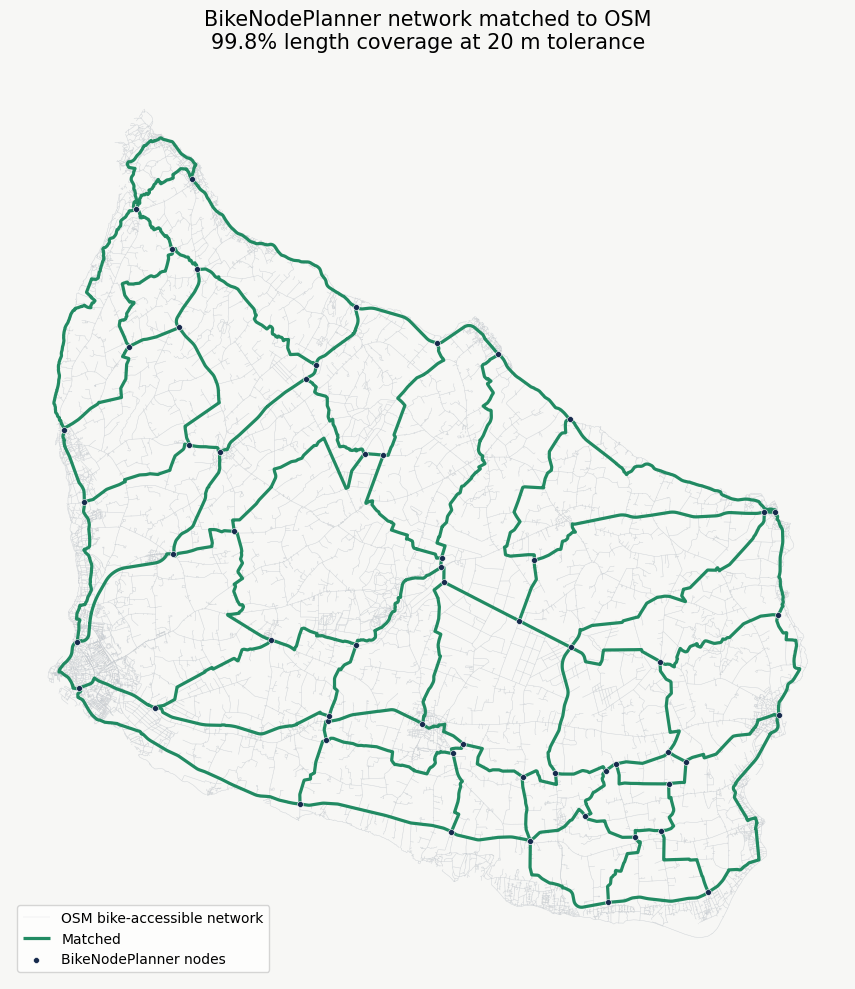

Saved map: outputs/bornholm_osm_matching/bikenodeplanner_osm_edge_matches.png


In [46]:
match_colors = {
    "Matched": "#16855b",
    "Partial match": "#f0a202",
    "Unmatched": "#d94841",
}

fig, ax = plt.subplots(
    figsize=(11, 10),
    facecolor="#f7f7f5",
)

# Full OSM bicycle-accessible network in the background.
osm_edges.plot(
    ax=ax,
    color="#c9ced3",
    linewidth=0.3,
    alpha=0.55,
    zorder=1,
    label="OSM bike-accessible network",
)

# BikeNodePlanner links, colored by match class.
for match_class, color in match_colors.items():
    selection = bikenode_edges.loc[
        bikenode_edges["match_class"] == match_class
    ]

    if not selection.empty:
        selection.plot(
            ax=ax,
            color=color,
            linewidth=2.3,
            alpha=0.95,
            label=match_class,
            zorder=3,
        )

# BikeNodePlanner nodes.
bikenode_nodes.plot(
    ax=ax,
    color="#172b4d",
    edgecolor="white",
    linewidth=0.4,
    markersize=18,
    label="BikeNodePlanner nodes",
    zorder=4,
)

ax.set_title(
    "BikeNodePlanner network matched to OSM\n"
    f"{overall_coverage_pct:.1f}% length coverage "
    f"at {MATCH_TOLERANCE_M} m tolerance",
    fontsize=15,
    pad=14,
)

ax.legend(
    loc="lower left",
    frameon=True,
)

ax.set_axis_off()
ax.set_aspect("equal")

fig.tight_layout()

figure_path = (
    OUTPUT_DIR
    / "bikenodeplanner_osm_edge_matches.png"
)

fig.savefig(
    figure_path,
    dpi=240,
    bbox_inches="tight",
    facecolor=fig.get_facecolor(),
)

plt.show()

print("Saved map:", figure_path)

In [47]:
least_matched_edges = (
    bikenode_edges[
        [
            "edge_id",
            "node_start",
            "node_end",
            "study_length_m",
            "covered_length_m",
            "coverage_pct",
            "match_class",
            "osm_ids",
            "osm_names",
            "osm_highways",
        ]
    ]
    .sort_values("coverage_pct")
    .head(20)
)

display(least_matched_edges.round(2))

,edge_id,node_start,node_end,study_length_m,covered_length_m,coverage_pct,match_class,osm_ids,osm_names,osm_highways
65,65,40,47,10499.53,9872.47,94.03,Matched,107613506; 107613518; 108342065; 110277922; 11...,Flæskedalsvej; Gamlevældevej; Kildevad; Kobbev...,cycleway; path; residential; secondary; servic...
88,88,57,58,3707.19,3623.97,97.76,Matched,118434977; 120076463; 124080853; 1283199412; 1...,Kajbjergvej; Moseløkkevej; Nordre Borrelyngvej...,cycleway; path; residential; secondary; servic...
49,49,29,38,6263.73,6153.11,98.23,Matched,1007851816; 1007851817; 102542461; 102546055; ...,Ahlstrandsvej; Antoinettevej; Baggårdsvej; Bag...,cycleway; path; residential; secondary; servic...
25,25,13,17,6357.48,6284.88,98.86,Matched,107079048; 107079090; 107085316; 108464715; 10...,Bodelynghusevejen; Bodelyngsvejen; Engegårdsve...,residential; service; tertiary; track; unclass...
46,46,27,33,5389.03,5364.94,99.55,Matched,107395295; 116634337; 116634338; 1282443320; 1...,Almindingsvej; Axelbærvejen; Kong Frederik d. ...,cycleway; path; service; tertiary; track; uncl...
37,37,22,23,199.67,199.67,100.00,Matched,1292149544; 135592989; 135593141; 270327368; 4...,Rønnevej; Smørengevejen,cycleway; primary; unclassified
35,35,21,22,3919.85,3919.85,100.00,Matched,104138030; 108464737; 108464744; 108464745; 10...,Birgersvej; Brovangen; Kalbyvejen; Kannikevang...,cycleway; path; primary; residential; service;...
19,19,10,15,2787.06,2787.06,100.00,Matched,101786540; 101786549; 1051678779; 1051678780; ...,Brandsgårdsvejen; Fredenlundsvej; Mejeribakken...,residential; service; unclassified
68,68,42,45,1356.35,1356.35,100.00,Matched,1057268864; 107284055; 108354760; 1207304014; ...,Fejlerevej; Klemens Storegade; Simblegårdsvej,path; service; tertiary; track; unclassified
12,12,6,8,6181.67,6181.67,100.00,Matched,105572744; 105572745; 106931484; 106931490; 10...,Bodernevej; Dalegårdsvej; Limensgaden; Sosevej...,cycleway; path; service; tertiary; track; uncl...


In [48]:
edge_gpkg_path = (
    OUTPUT_DIR
    / "bikenode_edges_matched_to_osm.gpkg"
)

edge_csv_path = (
    OUTPUT_DIR
    / "bikenode_edges_matched_to_osm.csv"
)

summary_csv_path = (
    OUTPUT_DIR
    / "matching_summary.csv"
)

bikenode_edges.to_file(
    edge_gpkg_path,
    layer="edge_matches",
    driver="GPKG",
)

bikenode_edges.drop(
    columns="geometry"
).to_csv(
    edge_csv_path,
    index=False,
)

summary.to_csv(
    summary_csv_path,
    index=False,
)

print("Saved matched edges:", edge_gpkg_path)
print("Saved edge table:", edge_csv_path)
print("Saved summary:", summary_csv_path)

Saved matched edges: outputs/bornholm_osm_matching/bikenode_edges_matched_to_osm.gpkg
Saved edge table: outputs/bornholm_osm_matching/bikenode_edges_matched_to_osm.csv
Saved summary: outputs/bornholm_osm_matching/matching_summary.csv
